In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sidmcommon.nsphere import read_particles_all_sim, read_auxillary_sim
from sidmcommon.particles import get_total_energy_snap
from sidmcommon.const import Const

In [ ]:
def get_total_energy_fixed_snap(snap, G=Const.G_KPC_MYR):
    mass = snap['mass']
    radius = snap['R']
    vrad = snap['Vrad']
    l = snap['L']

    r_inv = np.flip(1.0 / radius)
    outer_sum = np.flip(np.cumsum(np.flip(r_inv)))
    print(outer_sum)
    
    
    
    E_grav = - G * mass / radius
    E_kin = 0.5 * (vrad**2 + (l / radius)**2)
    

In [2]:
def get_particles_bound_snap(snap):
    energies = get_total_energy_snap(snap)
    ibound = np.where(energies < 0)[0]    

    selected = np.asarray(snap[ibound])
    
    mass_particle = np.max(snap['mass']) / snap.shape[0]
    selected['mass'] = mass_particle * np.arange(selected.shape[0])

    return selected
    
def get_particles_bound(particles):
    out = []
    for snap in particles:
        out.append(get_particles_bound_snap(snap))
    return out

In [3]:
path_sim = './data/isolated'
particles = read_particles_all_sim(path_sim)
particles_bound = get_particles_bound(particles)
aux = read_auxillary_sim(path_sim)

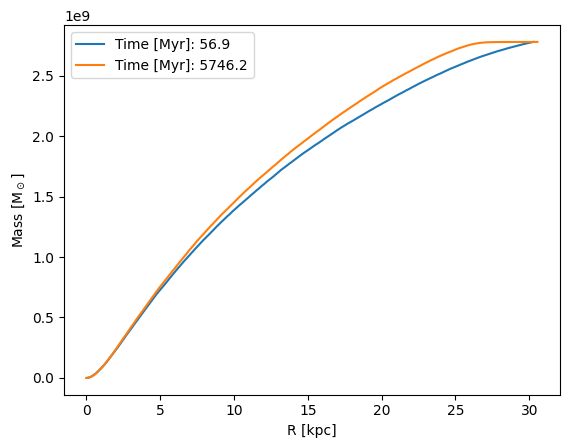

In [26]:
isnaps = [0, -1] 


for isnap in isnaps:
    #plt.plot(particles_bound[isnap]['R'], particles_bound[isnap]['mass'])
    plt.plot(particles[isnap]['R'], particles[isnap]['mass'], label=f'Time [Myr]: {aux["timestep"][isnap]:.1f}')

plt.legend()
plt.xlabel('R [kpc]')
plt.ylabel(r'Mass [M$_\odot$]')
plt.savefig('./plots/mass_vs_radius.png')



In [5]:
def get_indexes_bound_particles(snap):
    """Return the rank of bound particles in a snapshot."""
    e = get_total_energy_snap(snap)    
    return np.where(e < 0)[0]

def get_nsphere_vcirc_profile(snap, bound_only=True):
    """Squared circular velocity profile for a single snapshot."""
    m = snap['mass']
    r = snap['R']

    
    return np.sqrt(Const.G_KPC_MYR * m / r), r


def get_nsphere_vmax(data):
    """
    Maximum circular velocity at each output snapshot.

    Parameters
    ----------
    data : ndarray, shape (nsteps, nparticles)
        Particle data returned by read_particles_all_sim().
        Fields: rank (i32), R (f32, kpc), Vrad (f32, kpc/Myr),
                L (f32, kpc²/Myr), mass (f64, M☉ cumulative).

    Returns
    -------
    vmax : ndarray, shape (nsteps,)
        V_max in kpc/Myr at each snapshot.
    """
    vmax = np.zeros(len(data))
    for isnap, snap in enumerate(data):
        vmax[isnap] = np.max(get_nsphere_vcirc_profile(snap)[0])
    return vmax


def get_nsphere_rmax(data):
    """
    Radius of maximum circular velocity at each output snapshot.

    Parameters
    ----------
    data : ndarray, shape (nsteps, nparticles)
        Particle data returned by read_particles_all_sim().

    Returns
    -------
    rmax : ndarray, shape (nsteps,)
        R_max in kpc at each snapshot.
    """
    rmax = np.zeros(len(data))
    for isnap, snap in enumerate(data):
        vc, r = get_nsphere_vcirc_profile(snap)
        rmax[isnap] = r[np.argmax(vc)]
    return rmax



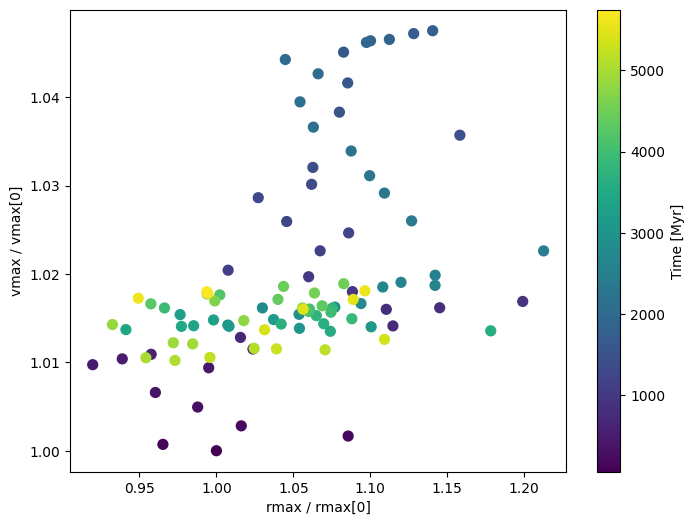

In [24]:
vmax = get_nsphere_vmax(particles)
rmax = get_nsphere_rmax(particles)
time = aux['timestep']

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    rmax / rmax[0],
    vmax / vmax[0],
    c=time,
    cmap='viridis',
    s=50
)
plt.colorbar(scatter, label='Time [Myr]')

plt.xlabel('rmax / rmax[0]')
plt.ylabel('vmax / vmax[0]')

plt.savefig('plots/tidal_tracks_isolated.png')